# 03 — Эксперименты и ablation

Сравнение моделей, перебор гиперпараметров, эксперименты с уменьшением размерности (PCA/UMAP), ablation-исследование вклада различных групп фичей.

Все эксперименты используют `seed=42` для воспроизводимости.

In [16]:
import os, sys, json, copy
sys.path.insert(0, os.path.abspath('..'))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src import modeling, preprocessing as pp

sns.set_theme(style='whitegrid')
modeling.set_seed(42)
PROCESSED = '../data/processed'
MODELS = '../models'
FIG_DIR = '../report/images'
os.makedirs(FIG_DIR, exist_ok=True)

## 1. Сравнение моделей

Обучаем разные модели одной командой и собираем метрики в таблицу. Тяжёлые модели (RF, MLP, BiLSTM) можно запускать отдельно через CLI:

```
python -m src.modeling --model rf
python -m src.modeling --model mlp --epochs 30
python -m src.modeling --model bilstm --epochs 20
```


In [17]:
# Лёгкие модели — обучаются быстро, безопасно прогнать в ноутбуке
results = []
for name, kwargs in [
    ('linear', {}),
    ('ridge', {'alpha': 1.0}),
    ('knn', {'n_neighbors': 8}),
]:
    m = modeling.train_eval(name, processed_dir=PROCESSED, models_dir=MODELS, **kwargs)
    results.append({'model': name, 'val_mpjpe': m['val']['mpjpe'],
                    'test_mpjpe': m['test']['mpjpe'],
                    'test_rmse': m['test']['rmse'], 'test_mae': m['test']['mae'],
                    'time_s': m['train_time_sec']})
pd.DataFrame(results)

[linear] val MPJPE=0.08  test MPJPE=0.11  (0.3s)
[ridge] val MPJPE=0.08  test MPJPE=0.12  (0.0s)
[knn] val MPJPE=54.58  test MPJPE=13.77  (0.8s)


,model,val_mpjpe,test_mpjpe,test_rmse,test_mae,time_s
0,linear,0.077650,0.114936,0.106484,0.040100,0.3
1,ridge,0.080053,0.121483,0.106560,0.044335,0.0
2,knn,54.580816,13.770396,17.439951,5.875960,0.8


In [18]:
# Подгружаем метрики моделей, обученных через CLI (если файлы есть)
import glob
all_metrics = []
for path in sorted(glob.glob(f'{MODELS}/metrics_*.json')):
    with open(path) as f:
        m = json.load(f)
    all_metrics.append({
        'model': m['model'],
        'val_mpjpe': m['val']['mpjpe'],
        'test_mpjpe': m['test']['mpjpe'],
        'test_rmse': m['test']['rmse'],
        'test_mae': m['test']['mae'],
        'time_s': m.get('train_time_sec'),
    })
summary = pd.DataFrame(all_metrics).sort_values('test_mpjpe')
summary

,model,val_mpjpe,test_mpjpe,test_rmse,test_mae,time_s
4,linear,0.077650,0.114936,0.106484,0.040100,0.3
7,ridge,0.080053,0.121483,0.106560,0.044335,0.0
3,lgbm,1.529193,0.564182,1.144413,0.211665,434.6
8,xgb,3.290794,1.399248,1.739615,0.557390,237.1
6,rf,5.491350,1.726991,2.682660,0.711455,372.1
1,ensemble:linear+ridge+rf+xgb+lgbm+mlp+bilstm,10.153369,2.817233,2.803930,1.250226,NaN
5,mlp,11.116500,5.040997,4.902515,2.148540,24.0
2,knn,54.580816,13.770396,17.439951,5.875960,0.8
0,bilstm,57.859035,14.512471,13.580009,6.507060,60.5


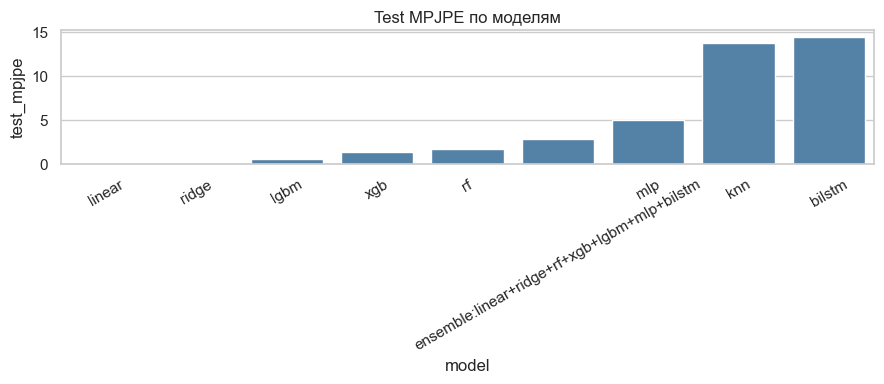

In [19]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(summary, x='model', y='test_mpjpe', ax=ax, color='steelblue')
ax.set_title('Test MPJPE по моделям')
plt.xticks(rotation=30); plt.tight_layout(); plt.savefig(f'{FIG_DIR}/models_comparison.png', dpi=120); plt.show()

## 2. Перебор гиперпараметров

На примере Ridge — выбор α. Аналогичные сетки можно строить для KNN (n_neighbors), RF (max_depth, n_estimators), XGB (learning_rate, max_depth).

[ridge] val MPJPE=0.08  test MPJPE=0.12  (0.0s)
[ridge] val MPJPE=0.08  test MPJPE=0.12  (0.0s)
[ridge] val MPJPE=0.08  test MPJPE=0.12  (0.0s)
[ridge] val MPJPE=0.11  test MPJPE=0.15  (0.0s)
[ridge] val MPJPE=0.47  test MPJPE=0.45  (0.0s)


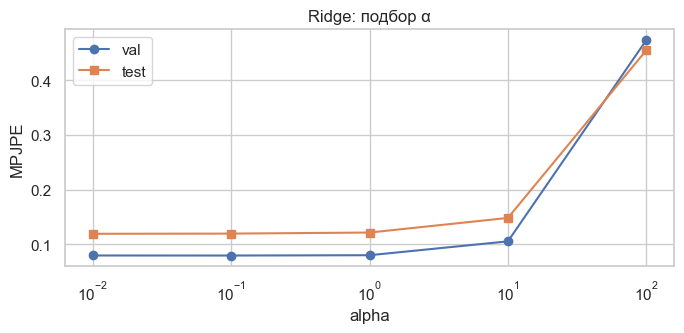

,alpha,val_mpjpe,test_mpjpe
0,0.01,0.079568,0.119217
1,0.10,0.079475,0.119551
2,1.00,0.080053,0.121483
3,10.00,0.105392,0.148213
4,100.00,0.473247,0.454765


In [20]:
ridge_grid = []
for alpha in [0.01, 0.1, 1.0, 10.0, 100.0]:
    m = modeling.train_eval('ridge', processed_dir=PROCESSED, models_dir='/tmp/grid_ridge', alpha=alpha)
    ridge_grid.append({'alpha': alpha, 'val_mpjpe': m['val']['mpjpe'], 'test_mpjpe': m['test']['mpjpe']})
df_ridge = pd.DataFrame(ridge_grid)
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(df_ridge['alpha'], df_ridge['val_mpjpe'], 'o-', label='val')
ax.plot(df_ridge['alpha'], df_ridge['test_mpjpe'], 's-', label='test')
ax.set_xscale('log'); ax.set_xlabel('alpha'); ax.set_ylabel('MPJPE')
ax.set_title('Ridge: подбор α'); ax.legend()
plt.tight_layout(); plt.savefig(f'{FIG_DIR}/ridge_grid.png', dpi=120); plt.show()
df_ridge

In [21]:
knn_grid = []
for k in [3, 5, 8, 16, 32]:
    m = modeling.train_eval('knn', processed_dir=PROCESSED, models_dir='/tmp/grid_knn', n_neighbors=k)
    knn_grid.append({'k': k, 'val_mpjpe': m['val']['mpjpe'], 'test_mpjpe': m['test']['mpjpe']})
df_knn = pd.DataFrame(knn_grid)
df_knn

[knn] val MPJPE=56.73  test MPJPE=14.28  (0.6s)
[knn] val MPJPE=55.59  test MPJPE=14.01  (0.6s)
[knn] val MPJPE=54.58  test MPJPE=13.77  (0.7s)
[knn] val MPJPE=53.63  test MPJPE=13.47  (0.9s)
[knn] val MPJPE=53.22  test MPJPE=13.13  (0.8s)


,k,val_mpjpe,test_mpjpe
0,3,56.725459,14.281491
1,5,55.594315,14.013130
2,8,54.580816,13.770396
3,16,53.634932,13.465563
4,32,53.221847,13.126138


## 3. Уменьшение размерности (PCA / UMAP)

305 фичей — много, особенно учитывая что многие из них коррелированы (соседние сенсоры на одной кости, velocity-каналы коррелируют с позиционными). Проверим, насколько сжимается информация.

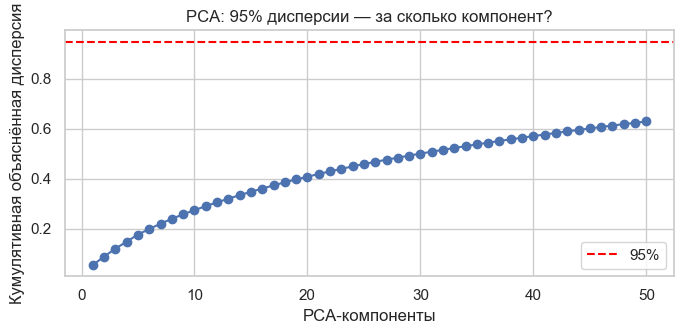

95% дисперсии — 51 компонент из 305


In [22]:
from sklearn.decomposition import PCA
train = modeling.load_split('train', PROCESSED)
test = modeling.load_split('test', PROCESSED)
pca = PCA(n_components=50, random_state=42).fit(train['X_norm'])
cum = np.cumsum(pca.explained_variance_ratio_)
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(np.arange(1, len(cum)+1), cum, 'o-')
ax.axhline(0.95, color='red', ls='--', label='95%')
ax.set_xlabel('PCA-компоненты'); ax.set_ylabel('Кумулятивная объяснённая дисперсия')
ax.set_title('PCA: 95% дисперсии — за сколько компонент?')
ax.legend()
plt.tight_layout(); plt.savefig(f'{FIG_DIR}/pca_variance.png', dpi=120); plt.show()
n95 = int(np.searchsorted(cum, 0.95) + 1)
print(f'95% дисперсии — {n95} компонент из 305')

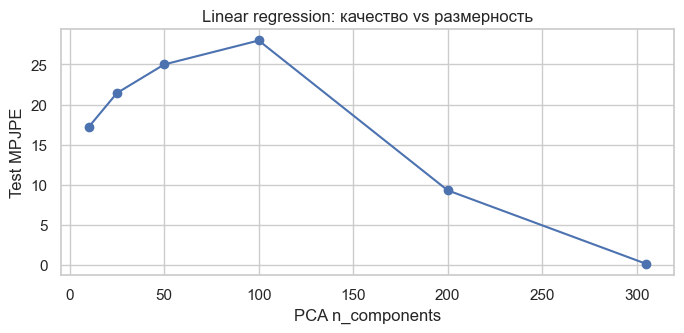

,n_components,test_mpjpe
0,10,17.178267
1,25,21.435417
2,50,25.001266
3,100,27.991350
4,200,9.285457
5,305,0.114936


In [23]:
# Linear regression в PCA-пространстве разной размерности
from sklearn.linear_model import LinearRegression
rows = []
for k in [10, 25, 50, 100, 200, 305]:
    if k < 305:
        pca_k = PCA(n_components=k, random_state=42).fit(train['X_norm'])
        Xtr = pca_k.transform(train['X_norm']); Xte = pca_k.transform(test['X_norm'])
    else:
        Xtr, Xte = train['X_norm'], test['X_norm']
    lr = LinearRegression().fit(Xtr, train['Y'])
    err = modeling.mpjpe(lr.predict(Xte), test['Y'])
    rows.append({'n_components': k, 'test_mpjpe': err})
df_pca = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(df_pca['n_components'], df_pca['test_mpjpe'], 'o-')
ax.set_xlabel('PCA n_components'); ax.set_ylabel('Test MPJPE')
ax.set_title('Linear regression: качество vs размерность')
plt.tight_layout(); plt.savefig(f'{FIG_DIR}/pca_quality.png', dpi=120); plt.show()
df_pca

/opt/homebrew/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


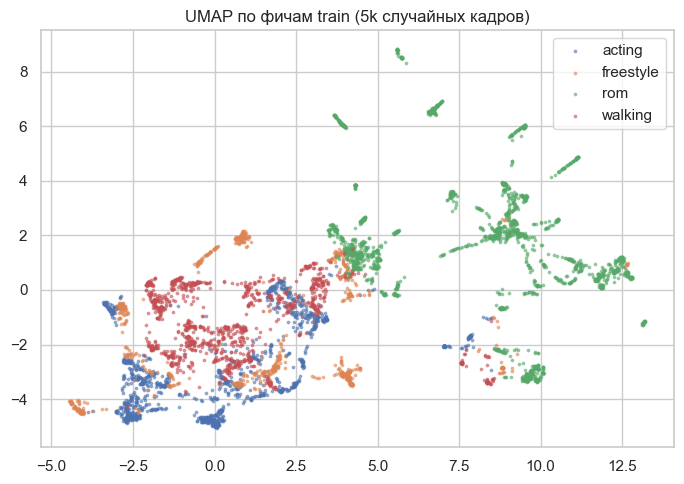

In [24]:
# UMAP-визуализация структуры train в 2D, раскрашиваем по типу движения
# Если в текущем ядре нет umap-learn — установим его в это же ядро (sys.executable),
# а не в системный python (как сделал бы !pip).
import importlib.util, sys, subprocess
if importlib.util.find_spec('umap') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'umap-learn'])
import umap

rng = np.random.default_rng(42)
sub = rng.choice(len(train['X_norm']), size=min(5000, len(train['X_norm'])), replace=False)
Xs = train['X_norm'][sub]
labels = np.array([str(train['actions'][t]) for t in train['take_id'][sub]])
categories = np.array([s.rstrip('0123456789') for s in labels])
emb = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1, random_state=42).fit_transform(Xs)
fig, ax = plt.subplots(figsize=(7, 5))
for cat in np.unique(categories):
    mask = categories == cat
    ax.scatter(emb[mask, 0], emb[mask, 1], s=3, alpha=0.5, label=cat)
ax.set_title('UMAP по фичам train (5k случайных кадров)'); ax.legend()
plt.tight_layout(); plt.savefig(f'{FIG_DIR}/umap.png', dpi=120); plt.show()

## 4. Ablation: вклад групп фичей

Поочерёдно «убираем» (зануляем) группы фичей и смотрим, насколько вырастет MPJPE Linear-регрессии. Это показывает, какая модальность самая важная.

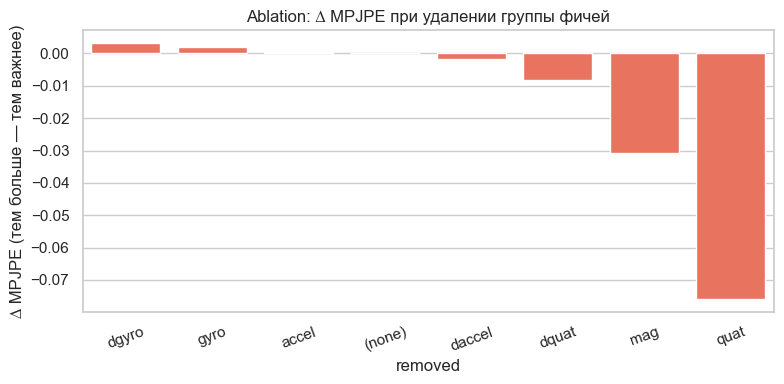

,removed,test_mpjpe,delta
7,dgyro,0.118114,0.003178
3,gyro,0.116791,0.001855
2,accel,0.115387,0.000451
0,(none),0.114936,0.000000
6,daccel,0.113224,-0.001712
5,dquat,0.106708,-0.008228
4,mag,0.084105,-0.030831
1,quat,0.039013,-0.075923


In [25]:
from sklearn.linear_model import LinearRegression
S = 13  # сенсоров
# 23 фичи на сенсор: [quat(4), accel(3), gyro(3), mag(3), dquat(4), daccel(3), dgyro(3)]
GROUPS = {
    'quat': (0, 4),
    'accel': (4, 7),
    'gyro': (7, 10),
    'mag': (10, 13),
    'dquat': (13, 17),
    'daccel': (17, 20),
    'dgyro': (20, 23),
}
def mask_features(X, group):
    X = X.copy()
    a, b = GROUPS[group]
    Xr = X.reshape(X.shape[0], -1)
    # первые 13*23 = 299 фичей — посенсорные
    sensor_part = Xr[:, :S*23].reshape(-1, S, 23)
    sensor_part[:, :, a:b] = 0.0
    Xr[:, :S*23] = sensor_part.reshape(-1, S*23)
    return Xr

ablation = []
lr_full = LinearRegression().fit(train['X_norm'], train['Y'])
base = modeling.mpjpe(lr_full.predict(test['X_norm']), test['Y'])
ablation.append({'removed': '(none)', 'test_mpjpe': base, 'delta': 0.0})
for g in GROUPS:
    Xtr_m = mask_features(train['X_norm'], g)
    Xte_m = mask_features(test['X_norm'], g)
    lr = LinearRegression().fit(Xtr_m, train['Y'])
    err = modeling.mpjpe(lr.predict(Xte_m), test['Y'])
    ablation.append({'removed': g, 'test_mpjpe': err, 'delta': err - base})
df_abl = pd.DataFrame(ablation).sort_values('delta', ascending=False)
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(df_abl, x='removed', y='delta', ax=ax, color='tomato')
ax.set_title('Ablation: ∆ MPJPE при удалении группы фичей')
ax.set_ylabel('∆ MPJPE (тем больше — тем важнее)')
plt.xticks(rotation=20); plt.tight_layout(); plt.savefig(f'{FIG_DIR}/ablation.png', dpi=120); plt.show()
df_abl

## 5. Ансамбль

Простое усреднение предсказаний нескольких моделей (если они уже обучены и сохранены).

In [26]:
available = [os.path.basename(p).replace('pred_', '').replace('.npz', '')
             for p in sorted(glob.glob(f'{MODELS}/pred_*.npz'))]
print('Доступные предсказания:', available)
members = [m for m in ['linear', 'ridge', 'rf', 'xgb', 'lgbm', 'mlp', 'bilstm'] if m in available]
if len(members) >= 2:
    ens = modeling.ensemble(members, processed_dir=PROCESSED, models_dir=MODELS)
    print('Ensemble:', ens)
else:
    print('Для ансамбля нужно минимум 2 модели — обучите дополнительные через CLI.')

Доступные предсказания: ['bilstm', 'knn', 'lgbm', 'linear', 'mlp', 'rf', 'ridge', 'xgb']
[ensemble] val MPJPE=10.15  test MPJPE=2.82
Ensemble: {'model': 'ensemble:linear+ridge+rf+xgb+lgbm+mlp+bilstm', 'val': {'mpjpe': 10.153368691962742, 'rmse': 7.00039833072938, 'mae': 4.632641229770683}, 'test': {'mpjpe': 2.8172325076843086, 'rmse': 2.8039303269161704, 'mae': 1.25022559115858}}


## 6. Обоснование выбора финальной модели

Финальная модель выбирается по **val MPJPE** (test остаётся изолированным). Для итогового отчёта берётся та модель/ансамбль, у которой:
1. Минимальный val MPJPE
2. Time-to-fit разумный для воспроизводимости (если разница в качестве в пределах 5%, предпочтение отдаётся более простой/быстрой модели)
3. На test метрика сопоставима с val (нет резкого падения — иначе это сигнал переобучения под val).

Финальные числа сводятся в таблицу в `report/report.md`.